<a href="https://colab.research.google.com/github/pinballsurgeon/deluxo_adjacency/blob/main/diffusion_linear_emergence_precursor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# linear emergence - lofi precursors

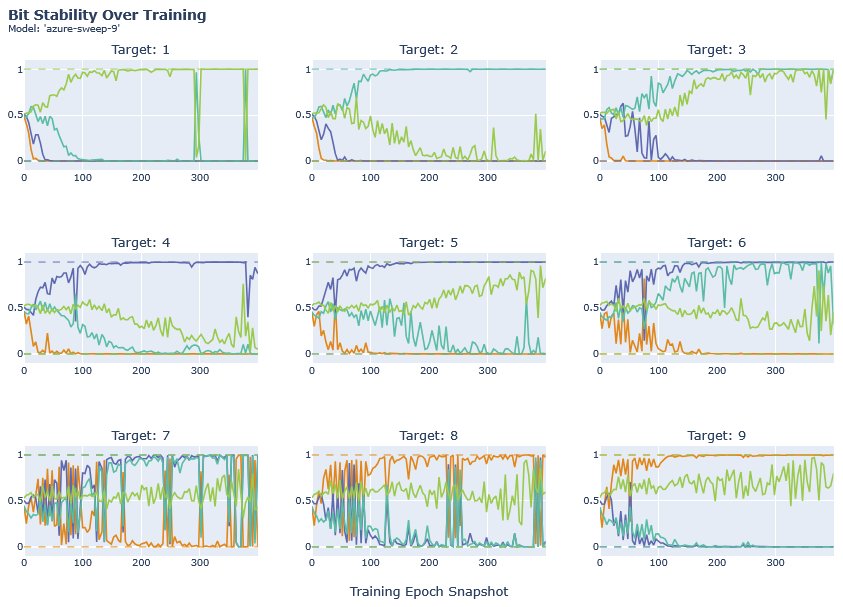

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import pandas as pd
import plotly.express as px
from scipy.fft import fft, fftfreq
from sklearn.cluster import KMeans
import warnings
import wandb
import os
import copy
import gzip

warnings.filterwarnings("ignore", category=FutureWarning)

class TinyBinaryDiffusionModel(nn.Module):
    def __init__(self, layer_width, num_layers):
        super().__init__()
        layers = [nn.Linear(6, layer_width), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers.extend([nn.Linear(layer_width, layer_width), nn.ReLU()])
        layers.extend([nn.Linear(layer_width, 4), nn.Sigmoid()])
        self.net = nn.Sequential(*layers)

    def forward(self, noised_vector, condition_number, timestep, max_timesteps):
        norm_timestep = timestep / max_timesteps
        net_input = torch.cat([noised_vector, condition_number, norm_timestep], dim=1)
        return self.net(net_input)

GROUND_TRUTH = {
    1: [0, 0, 0, 1], 2: [0, 0, 1, 0], 3: [0, 0, 1, 1], 4: [0, 1, 0, 0],
    5: [0, 1, 0, 1], 6: [0, 1, 1, 0], 7: [0, 1, 1, 1], 8: [1, 0, 0, 0], 9: [1, 0, 0, 1],
}
REVERSED_GROUND_TRUTH = {tuple(v): k for k, v in GROUND_TRUTH.items()}
FROZEN_START_NOISE = torch.tensor([[1., 0., 1., 0.]])
TARGET_NUMBER = 7

def forward_process(clean_vector, t, max_timesteps):
    flip_prob = t / max_timesteps
    noise_mask = (torch.rand_like(clean_vector) < flip_prob).float()
    return clean_vector * (1 - noise_mask) + (1 - clean_vector) * noise_mask, noise_mask

conditions = torch.tensor(list(GROUND_TRUTH.keys()), dtype=torch.float32).unsqueeze(1)
clean_data = torch.tensor(list(GROUND_TRUTH.values()), dtype=torch.float32)
dataset = TensorDataset(conditions, clean_data)
DEFAULT_BATCH_SIZE = 16
dataloader = DataLoader(dataset, batch_size=DEFAULT_BATCH_SIZE, shuffle=True)

def binary_to_number(binary_tensor):
    binary_tuple = tuple(binary_tensor.round().numpy().flatten().astype(int))
    return REVERSED_GROUND_TRUTH.get(binary_tuple, 0)

def get_denoising_trajectory(model, number_to_generate, start_noise, max_timesteps):
    trajectory = []
    model.eval()
    with torch.no_grad():
        current_vector = start_noise.clone()
        condition = torch.tensor([[number_to_generate]], dtype=torch.float32)
        for t in range(max_timesteps, 0, -1):
            timestep_tensor = torch.tensor([[t]], dtype=torch.float32)
            predicted_clean = model(current_vector, condition, timestep_tensor, max_timesteps)
            trajectory.append(predicted_clean.numpy().flatten())
            current_vector = predicted_clean.round()
    return np.array(trajectory)

def analyze_trajectory_fft(trajectory_signal):
    N = len(trajectory_signal)
    if N == 0: return np.array([]), np.array([])
    signal_detrended = trajectory_signal - np.mean(trajectory_signal)
    yf = fft(signal_detrended)
    xf = fftfreq(N, 1)[:N//2]
    power = 2.0/N * np.abs(yf[0:N//2])
    return xf, power

def get_spectral_centroid(frequencies, power):
    return np.sum(frequencies * power) / (np.sum(power) + 1e-9)

def train():
    with wandb.init() as run:
        config = wandb.config
        run_dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)
        model = TinyBinaryDiffusionModel(
            layer_width=config.layer_width,
            num_layers=config.model_depth
        ).to("cpu")
        optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
        loss_fn = nn.MSELoss()

        loss_history = []
        model_snapshots = {}
        epochs_to_capture = set(np.linspace(0, config.epochs - 1, NUM_SNAPSHOTS).astype(int))

        for epoch in tqdm(range(config.epochs), desc=f"Run {run.name}", leave=False):
            for batch_conditions, batch_clean_data in run_dataloader:
                optimizer.zero_grad()
                t = torch.randint(1, config.diffusion_timesteps + 1, (batch_clean_data.size(0), 1))
                batch_noised, _ = forward_process(batch_clean_data, t, config.diffusion_timesteps)
                predicted_clean = model(batch_noised, batch_conditions, t.float(), config.diffusion_timesteps)
                loss = loss_fn(predicted_clean, batch_clean_data)
                loss.backward()
                optimizer.step()
                loss_history.append(loss.item())

            wandb.log({"epoch": epoch, "mean_epoch_loss": np.mean(loss_history[-len(run_dataloader):])})

            if epoch in epochs_to_capture:
                model_snapshots[epoch] = copy.deepcopy(model.state_dict())

        epochs_sorted = sorted(model_snapshots.keys())
        temp_model = TinyBinaryDiffusionModel(config.layer_width, config.model_depth)
        accuracies = {}
        for epoch in epochs_sorted:
            temp_model.load_state_dict(model_snapshots[epoch])
            correct_preds = 0
            for num in range(1, 10):
                temp_model.eval()
                with torch.no_grad():
                    current_vector = FROZEN_START_NOISE.clone()
                    condition = torch.tensor([[num]], dtype=torch.float32)
                    for t in range(config.diffusion_timesteps, 0, -1):
                        timestep_tensor = torch.tensor([[t]], dtype=torch.float32)
                        predicted_clean = temp_model(current_vector, condition, timestep_tensor, config.diffusion_timesteps)
                        current_vector = predicted_clean.round()
                if binary_to_number(current_vector) == num:
                    correct_preds += 1
            accuracies[epoch] = correct_preds / 9.0

        best_epoch = max(accuracies, key=accuracies.get) if accuracies else -1
        best_accuracy = accuracies.get(best_epoch, 0)
        first_100_epoch = next((e for e, acc in accuracies.items() if acc == 1.0), -1)

        wandb.summary["best_accuracy"] = best_accuracy
        wandb.summary["best_epoch"] = best_epoch
        wandb.summary["first_100_epoch"] = first_100_epoch if first_100_epoch != -1 else config.epochs

        fig_perf, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
        fig_perf.suptitle(f"Performance Metrics for: {run.name}", fontsize=16)
        ax1.plot(loss_history)
        ax1.set_title("Training Loss (Steps)")
        ax1.set_xlabel("Training Step")
        ax1.set_ylabel("MSE Loss")
        ax1.set_yscale('log')
        ax1.grid(True, alpha=0.5)
        ax2.plot(list(accuracies.keys()), list(accuracies.values()), 'o-')
        ax2.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
        if first_100_epoch != -1:
            ax2.axvline(x=first_100_epoch, color='g', linestyle='--', label=f'First 100% Acc')
        ax2.set_title("Overall Accuracy Over Training")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Accuracy")
        ax2.grid(True, alpha=0.5)
        ax2.legend()
        ax2.set_ylim(-0.05, 1.05)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        wandb.log({"Performance Plots": wandb.Image(fig_perf)})
        plt.close(fig_perf)

        model_artifact_path = "model.pt"
        torch.save(model.state_dict(), model_artifact_path)
        artifact = wandb.Artifact(
            name=f"model-{run.id}",
            type="model",
            description=f"Final trained model for run {run.name} after {config.epochs} epochs.",
            metadata=dict(config)
        )
        artifact.add_file(model_artifact_path)
        run.log_artifact(artifact)

NUM_SNAPSHOTS = 100

In [5]:
import wandb
wandb.login()

WANDB_PROJECT_NAME = "Advanced_Binary_Diffusion_HPO"

sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'best_accuracy',
        'goal': 'maximize'
    },
    'parameters': {
        'layer_width': {
            'distribution': 'q_log_uniform_values',
            'min': 16,
            'max': 512,
            'q': 16
        },
        'model_depth': {
            'values': [2, 3, 4, 5]
        },
        'learning_rate': {
            'distribution': 'log_uniform_values',
            'min': 1e-6,
            'max': 1e-1
        },
        'diffusion_timesteps': {
            'values': [25, 50, 75, 100]
        },
        'batch_size': {
            'values': [32]
        },
        'epochs': {
            'value': 400
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT_NAME)

NUM_RUNS_TO_EXECUTE = 10

wandb.agent(sweep_id, function=train, count=NUM_RUNS_TO_EXECUTE)

Create sweep with ID: 4qma2bp5
Sweep URL: https://wandb.ai/pinballsurgeon-onix/Advanced_Binary_Diffusion_HPO/sweeps/4qma2bp5


wandb: Agent Starting Run: oou3goc1 with config:
wandb: 	batch_size: 32
wandb: 	diffusion_timesteps: 75
wandb: 	epochs: 400
wandb: 	layer_width: 32
wandb: 	learning_rate: 2.654982545678617e-06
wandb: 	model_depth: 4


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇███
mean_epoch_loss,▄▆▄█▄▆▇█▅▃▆▅▆▅▁▅▅▅▂▃▆▃▃▅▅▂▄▃▁▄▁▂▂▃▂▄▁▁▃▁
best_accuracy,0.11111
best_epoch,0
epoch,399
first_100_epoch,400
mean_epoch_loss,0.24648


wandb: Agent Starting Run: n2yu457u with config:
wandb: 	batch_size: 32
wandb: 	diffusion_timesteps: 50
wandb: 	epochs: 400
wandb: 	layer_width: 224
wandb: 	learning_rate: 0.01768343246087635
wandb: 	model_depth: 4


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇██████
mean_epoch_loss,█▅▄▅▄▄▄▄▃▃▂▃▃▃▁▄▃▂▃▃▁▁▄▂▃▅▃▄▃▄▃▂▃▃▂▃▂▂▂▂
best_accuracy,0.88889
best_epoch,189
epoch,399
first_100_epoch,400
mean_epoch_loss,0.08348


...

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇█
mean_epoch_loss,█▅▅▅▂▃▃▃▄▄▄▃▃▃▃▅▅▂▃▃▃▇▄▃▄▂▂▂▂▂▂▅▅▂▃▂▂▁▁▁
best_accuracy,1
best_epoch,370
epoch,399
first_100_epoch,370
mean_epoch_loss,0.00644


wandb: Agent Starting Run: v57w4ujn with config:
wandb: 	batch_size: 32
wandb: 	diffusion_timesteps: 100
wandb: 	epochs: 400
wandb: 	layer_width: 64
wandb: 	learning_rate: 0.012581455077648214
wandb: 	model_depth: 5


epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█████
mean_epoch_loss,█▇▆▆▅▅▆▅▅▄▅▄▃▃▃▂▂▂▂▃▁▁▃▁▁▃▅▇▃▅▂▅▃▄▂▃▁▁▁▁
best_accuracy,1
best_epoch,394
epoch,399
first_100_epoch,394
mean_epoch_loss,0.01443


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: zpivuz09 with config:
wandb: 	batch_size: 32
wandb: 	diffusion_timesteps: 75
wandb: 	epochs: 400
wandb: 	layer_width: 480
wandb: 	learning_rate: 0.009083443763753358
wandb: 	model_depth: 4


epoch,▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇██
mean_epoch_loss,▅██▅▃▃▃▄▃▂▃▂▃▃▂▄▂▅▃▂▄▂▁▁▂▆▄▃▂▃▂▂▂▂▂▅▄▄▄▄
best_accuracy,0.88889
best_epoch,249
epoch,399
first_100_epoch,400
mean_epoch_loss,0.03316


In [6]:
import pandas as pd
import wandb
import os
import time
import gzip
from sklearn.ensemble import RandomForestRegressor
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

api = wandb.Api()
sweep = api.sweep(f"{api.default_entity}/{WANDB_PROJECT_NAME}/{sweep_id}")

runs_data = []
for run in sweep.runs:
    run_dict = {
        'run_id': run.id,
        'run_name': run.name,
        **run.config,
        **run.summary._json_dict
    }
    runs_data.append(run_dict)

summary_df = pd.DataFrame(runs_data)
summary_df = summary_df.loc[:, ~summary_df.columns.str.startswith('_')]

ARTIFACTS_DIR = "./artifacts"
new_metrics = []
for index, row in summary_df.iterrows():
    try:
        run = api.run(f"{api.default_entity}/{WANDB_PROJECT_NAME}/{row['run_id']}")
        model_artifact = None
        for art in run.logged_artifacts():
            if art.type == 'model':
                model_artifact = art
                break
        if not model_artifact:
            continue

        artifact_path = model_artifact.download(root=ARTIFACTS_DIR)
        model_file_path = os.path.join(artifact_path, "model.pt")

        model_size_bytes = os.path.getsize(model_file_path)
        model_size_mb = model_size_bytes / (1024 * 1024)

        with open(model_file_path, 'rb') as f_in:
            compressed_data = gzip.compress(f_in.read())
            compressed_size_bytes = len(compressed_data)
            compressed_size_mb = compressed_size_bytes / (1024 * 1024)
            compress_ratio = compressed_size_bytes / model_size_bytes if model_size_bytes > 0 else 0

        model = TinyBinaryDiffusionModel(layer_width=row['layer_width'], num_layers=row['model_depth'])
        model.load_state_dict(torch.load(model_file_path, map_location=torch.device('cpu')))
        model.eval()

        dummy_noise = torch.randn(1, 4)
        dummy_cond = torch.tensor([[5.]]); dummy_time = torch.tensor([[25.]])
        max_t = row['diffusion_timesteps']
        with torch.no_grad(): _ = model(dummy_noise, dummy_cond, dummy_time, max_t)

        start_time = time.time()
        num_inferences = 100
        with torch.no_grad():
            for _ in range(num_inferences):
                _ = model(dummy_noise, dummy_cond, dummy_time, max_t)
        end_time = time.time()
        avg_inference_time_ms = ((end_time - start_time) / num_inferences) * 1000

        new_metrics.append({
            'run_id': row['run_id'],
            'model_size_mb': model_size_mb,
            'compressed_size_mb': compressed_size_mb,
            'compress_ratio': compress_ratio,
            'inference_time_ms': avg_inference_time_ms
        })
    except Exception as e:
        new_metrics.append({'run_id': row['run_id']})

metrics_df = pd.DataFrame(new_metrics)
summary_df = pd.merge(summary_df, metrics_df, on='run_id', how='left')

analysis_df = summary_df.dropna(
    subset=['best_accuracy', 'layer_width', 'model_depth', 'learning_rate', 'diffusion_timesteps', 'model_size_mb']
)
if not analysis_df.empty:
    features = ['layer_width', 'model_depth', 'learning_rate', 'diffusion_timesteps', 'batch_size']
    X = analysis_df[features]
    y = analysis_df['best_accuracy']
    meta_model = RandomForestRegressor(n_estimators=100, random_state=42)
    meta_model.fit(X, y)
    importances = pd.DataFrame({
        'feature': features,
        'importance': meta_model.feature_importances_
    }).sort_values('importance', ascending=False)
    fig_importance = px.bar(
        importances, x='feature', y='importance',
        title="Which Hyperparameters Mattered Most for Achieving High Accuracy?",
        labels={'feature': 'Hyperparameter', 'importance': 'Importance Score'}
    )
    fig_importance.show()

plot_df = summary_df.dropna(subset=['best_accuracy', 'model_size_mb', 'inference_time_ms'])
if not plot_df.empty:
    best_run_id = plot_df.loc[plot_df['best_accuracy'].idxmax()]['run_id']
    best_run = api.run(f"{api.default_entity}/{WANDB_PROJECT_NAME}/{best_run_id}")
    all_histories = [r.history(keys=['epoch', 'mean_epoch_loss'], pandas=True).dropna() for r in sweep.runs]
    full_history_df = pd.concat(all_histories)
    avg_history = full_history_df.groupby('epoch')['mean_epoch_loss'].agg(['mean', 'std']).reset_index()
    best_run_history = best_run.history(keys=['epoch', 'mean_epoch_loss'], pandas=True)
    fig_best_vs_avg = go.Figure()
    fig_best_vs_avg.add_trace(go.Scatter(x=avg_history['epoch'], y=avg_history['mean'] + avg_history['std'], fill=None, mode='lines', line_color='rgba(0,100,80,0.2)'))
    fig_best_vs_avg.add_trace(go.Scatter(x=avg_history['epoch'], y=avg_history['mean'] - avg_history['std'], fill='tonexty', mode='lines', line_color='rgba(0,100,80,0.2)', name='Std Dev'))
    fig_best_vs_avg.add_trace(go.Scatter(x=avg_history['epoch'], y=avg_history['mean'], mode='lines', line=dict(color='rgba(0,100,80,1)', dash='dash'), name='Average Loss'))
    fig_best_vs_avg.add_trace(go.Scatter(x=best_run_history['epoch'], y=best_run_history['mean_epoch_loss'], mode='lines', line=dict(color='red', width=3), name=f'Best Run Loss'))
    fig_best_vs_avg.update_layout(title='Best Run Loss vs. Average of All Runs', xaxis_title='Epoch', yaxis_title='Mean Epoch Loss', yaxis_type='log')
    fig_best_vs_avg.show()

    fig_tradeoffs = make_subplots(rows=1, cols=3, subplot_titles=("Accuracy vs. Model Size", "Accuracy vs. Inference Speed", "Accuracy vs. Compressibility"))
    fig_tradeoffs.add_trace(go.Scatter(x=plot_df['model_size_mb'], y=plot_df['best_accuracy'], mode='markers', marker=dict(color=plot_df['learning_rate'], coloraxis="coloraxis"), text=plot_df['run_name']), row=1, col=1)
    fig_tradeoffs.add_trace(go.Scatter(x=plot_df['inference_time_ms'], y=plot_df['best_accuracy'], mode='markers', marker=dict(color=plot_df['learning_rate'], coloraxis="coloraxis"), text=plot_df['run_name']), row=1, col=2)
    fig_tradeoffs.add_trace(go.Scatter(x=plot_df['compress_ratio'], y=plot_df['best_accuracy'], mode='markers', marker=dict(color=plot_df['learning_rate'], coloraxis="coloraxis"), text=plot_df['run_name']), row=1, col=3)
    fig_tradeoffs.update_layout(title_text="Performance vs. Cost Trade-offs (Color mapped to Learning Rate)", coloraxis=dict(colorscale='Viridis', colorbar_title_text='Learning Rate'), showlegend=False)
    fig_tradeoffs.update_xaxes(title_text="Model Size (MB)", row=1, col=1); fig_tradeoffs.update_xaxes(title_text="Inference Time (ms)", row=1, col=2); fig_tradeoffs.update_xaxes(title_text="Compression Ratio", row=1, col=3)
    fig_tradeoffs.update_yaxes(title_text="Best Accuracy", range=[-0.05, 1.05])
    fig_tradeoffs.show()

    fig_parallel = px.parallel_coordinates(plot_df.sort_values('best_accuracy', ascending=False), color="best_accuracy", dimensions=['best_accuracy', 'first_100_epoch','model_size_mb', 'inference_time_ms', 'compress_ratio','learning_rate', 'layer_width', 'model_depth', 'diffusion_timesteps'], color_continuous_scale=px.colors.sequential.Viridis, title="Full HPO Results: Finding the Best Overall Model")
    fig_parallel.show()

    pd.set_option('display.max_columns', None)
    display(plot_df.sort_values('best_accuracy', ascending=False).reset_index(drop=True))

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


,run_id,run_name,epochs,batch_size,layer_width,model_depth,learning_rate,diffusion_timesteps,Performance Plots,best_accuracy,best_epoch,epoch,first_100_epoch,mean_epoch_loss,model_size_mb,compressed_size_mb,compress_ratio,inference_time_ms
0,v57w4ujn,fanciful-sweep-9,400,32,64,5,0.012581,100,"{'_type': 'image-file', 'format': 'png', 'heig...",1.000000,394,399,394,0.014428,0.069597,0.063122,0.906958,0.255780
1,qdttquyv,legendary-sweep-8,400,32,176,5,0.025283,75,"{'_type': 'image-file', 'format': 'png', 'heig...",1.000000,370,399,370,0.006437,0.486162,0.448859,0.923271,0.211146
2,zpivuz09,scarlet-sweep-10,400,32,480,4,0.009083,75,"{'_type': 'image-file', 'format': 'png', 'heig...",0.888889,249,399,400,0.033157,2.665432,2.457888,0.922135,0.526488
3,vu9t4g7g,snowy-sweep-6,400,32,112,5,0.021013,75,"{'_type': 'image-file', 'format': 'png', 'heig...",0.888889,298,399,400,0.056447,0.201250,0.184806,0.918290,0.164137
4,48u555c6,wise-sweep-5,400,32,208,4,0.007724,50,"{'_type': 'image-file', 'format': 'png', 'heig...",0.888889,266,399,400,0.032367,0.509243,0.471661,0.926199,0.168293
5,n2yu457u,vivid-sweep-2,400,32,224,4,0.017683,50,"{'_type': 'image-file', 'format': 'png', 'heig...",0.888889,189,399,400,0.083481,0.589199,0.544861,0.924748,0.169499
6,at114kew,still-sweep-7,400,32,192,5,0.049310,75,"{'_type': 'image-file', 'format': 'png', 'heig...",0.111111,0,399,400,0.388889,0.576921,0.534367,0.926238,0.216124
7,2wc9i23x,lyric-sweep-4,400,32,128,4,0.000005,50,"{'_type': 'image-file', 'format': 'png', 'heig...",0.111111,0,399,400,0.247899,0.197353,0.180159,0.912873,0.161026
8,qvenwbe4,vital-sweep-3,400,32,432,2,0.039052,25,"{'_type': 'image-file', 'format': 'png', 'heig...",0.111111,0,399,400,0.388889,0.733936,0.684052,0.932032,0.151770
9,oou3goc1,lucky-sweep-1,400,32,32,4,0.000003,75,"{'_type': 'image-file', 'format': 'png', 'heig...",0.111111,0,399,400,0.246482,0.016445,0.013730,0.834899,0.167711


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

df = plot_df.sort_values('best_accuracy', ascending=False).reset_index(drop=True)

fig_3d = px.scatter_3d(
    df,
    x='compress_ratio',
    y='model_depth',
    z='layer_width',
    color='best_accuracy',
    size='compress_ratio',
    hover_name='run_name',
    color_continuous_scale=px.colors.sequential.Viridis,
    log_z=True,
    title="<b>3D Hyperparameter Sweet Spot</b><br><sup>Color = Accuracy | Size = Model MB</sup>"
)
fig_3d.update_layout(
    scene=dict(
        xaxis_title='compress_ratio',
        yaxis_title='model_depth',
        zaxis_title='layer_width'
    ),
    legend_title="Best Accuracy",
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_3d.show()

params_to_analyze = ['layer_width', 'model_depth', 'diffusion_timesteps']

print(df.columns)

for param in params_to_analyze:
    trend_df = df.groupby(param).agg(
        avg_accuracy=('best_accuracy', 'mean'),
        avg_size_mb=('compress_ratio', 'mean'),
        avg_inference_ms=('inference_time_ms', 'mean')
    ).reset_index()

    fig_dual = make_subplots(specs=[[{"secondary_y": True}]])

    fig_dual.add_trace(
        go.Scatter(
            x=trend_df[param],
            y=trend_df['avg_accuracy'],
            name='Average Accuracy (Benefit)',
            mode='lines+markers',
            marker=dict(color='#1f77b4', size=10)
        ),
        secondary_y=False,
    )
    fig_dual.add_trace(
        go.Scatter(
            x=trend_df[param],
            y=trend_df['avg_size_mb'],
            name='Average Model Size (Cost)',
            mode='lines+markers',
            marker=dict(color='#d62728', size=10, symbol='square')
        ),
        secondary_y=True,
    )
    fig_dual.update_layout(
        title_text=f"<b>Trade-Off Analysis for: {param.replace('_', ' ').title()}</b><br><sup>Is more always better?</sup>",
        xaxis_title=f"{param.replace('_', ' ').title()}"
    )
    fig_dual.update_yaxes(title_text="<b>Benefit:</b> Average Accuracy", secondary_y=False, color='#1f77b4', range=[-0.05, 1.05])
    fig_dual.update_yaxes(title_text="<b>Cost:</b> Average Model Size (MB)", secondary_y=True, color='#d62728')
    fig_dual.show()

top_3_df = df.head(3)
profile_cols = [
    'run_name', 'best_accuracy', 'first_100_epoch',
    'model_size_mb', 'inference_time_ms', 'compress_ratio',
    'learning_rate', 'layer_width', 'model_depth', 'diffusion_timesteps'
]
profile_df = top_3_df[profile_cols]
profile_df_T = profile_df.set_index('run_name').T
profile_df_T.index.name = "Metric"

fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>Metric</b>'] + [f'<b>🏆 Rank {i+1}</b><br>{name}' for i, name in enumerate(profile_df_T.columns)],
        fill_color='paleturquoise',
        align='left',
        font=dict(size=14)
    ),
    cells=dict(
        values=[profile_df_T.index] + [profile_df_T[col].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x) for col in profile_df_T.columns],
        fill_color='lavender',
        align='left',
        font=dict(size=12)
    ))
])
fig_table.update_layout(
    title="<b>The Champions' Profile: A Head-to-Head Comparison of the Top 3 Models</b>",
    margin=dict(l=10, r=10, b=10, t=50)
)
fig_table.show()

Index(['run_id', 'run_name', 'epochs', 'batch_size', 'layer_width',
       'model_depth', 'learning_rate', 'diffusion_timesteps',
       'Performance Plots', 'best_accuracy', 'best_epoch', 'epoch',
       'first_100_epoch', 'mean_epoch_loss', 'model_size_mb',
       'compressed_size_mb', 'compress_ratio', 'inference_time_ms'],
      dtype='object')


In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import torch
import numpy as np
import pandas as pd
import os

top_model_df = df.sort_values('best_accuracy', ascending=False).iloc[0]
top_run_id = top_model_df['run_id']

run = api.run(f"{api.default_entity}/{WANDB_PROJECT_NAME}/{top_run_id}")

model_artifact = None
for art in run.logged_artifacts():
    if art.type == 'model':
        model_artifact = art
        break

if not model_artifact:
    raise RuntimeError(f"Could not find a model artifact for run {top_run_id}")

artifact_path = model_artifact.download(root=f"./artifacts/top_model")
model_file_path = os.path.join(artifact_path, "model.pt")

top_model = TinyBinaryDiffusionModel(
    layer_width=int(top_model_df['layer_width']),
    num_layers=int(top_model_df['model_depth'])
)
top_model.load_state_dict(torch.load(model_file_path, map_location=torch.device('cpu')))
top_model.eval()

def get_full_denoising_details(model, number_to_generate, config):
    trajectory = []
    max_timesteps = int(config['diffusion_timesteps'])
    with torch.no_grad():
        current_vector = FROZEN_START_NOISE.clone()
        condition = torch.tensor([[number_to_generate]], dtype=torch.float32)
        for t in range(max_timesteps, 0, -1):
            timestep_tensor = torch.tensor([[t]], dtype=torch.float32)
            predicted_clean = model(current_vector, condition, timestep_tensor, max_timesteps)
            trajectory.append(predicted_clean.numpy().flatten())
            current_vector = predicted_clean.round()
    return np.array(trajectory)

fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f"Target: {i}" for i in range(1, 10)],
    x_title="Denoising Timestep (t)",
    y_title="Output Bit Index"
)

trajectories_data = {}
for i in range(1, 10):
    row = (i - 1) // 3 + 1
    col = (i - 1) % 3 + 1
    trajectory = get_full_denoising_details(top_model, i, top_model_df)
    trajectories_data[i] = trajectory
    ground_truth_vector = np.array(GROUND_TRUTH[i])

    fig.add_trace(go.Heatmap(
        z=trajectory.T,
        x=np.arange(int(top_model_df['diffusion_timesteps']), 0, -1),
        y=[f'Bit {b+1}' for b in range(4)],
        colorscale='Viridis',
        zmin=0, zmax=1,
        colorbar=dict(title='Confidence', len=0.3, y=0.5, x=1.1)
    ), row=row, col=col)

    for bit_idx in range(4):
        fig.add_annotation(
            x=1, y=f'Bit {bit_idx+1}', text=f"<b>{ground_truth_vector[bit_idx]}</b>",
            showarrow=False, font=dict(color="white" if trajectory[-1, bit_idx] < 0.5 else "black", size=14),
            row=row, col=col
        )

fig.update_layout(
    title_text="<b>Top Model's Denoising Dashboard: Visualizing Bit Stability</b><br><sup>Each panel shows the model's confidence over time for a target number</sup>",
    height=800,
    width=1000,
    showlegend=False
)
for i in range(1, 10):
    fig.update_xaxes(autorange="reversed", row=(i - 1) // 3 + 1, col=(i - 1) % 3 + 1)
fig.show()

report_data = []
for target_num in range(1, 10):
    trajectory = trajectories_data[target_num]
    ground_truth = GROUND_TRUTH[target_num]
    max_t = trajectory.shape[0]
    row_report = {'Target #': target_num}
    for bit_idx in range(4):
        correct_val = ground_truth[bit_idx]
        lock_in_time = 'Failed'
        for t_step_idx in range(trajectory.shape[0] - 1, -1, -1):
            is_correct = (trajectory[t_step_idx, bit_idx] > 0.5) == (correct_val > 0.5)
            if is_correct:
                lock_in_time = max_t - t_step_idx
            else:
                break
        row_report[f'Bit {bit_idx+1} Lock-in (t)'] = lock_in_time
    report_data.append(row_report)

report_df = pd.DataFrame(report_data).set_index('Target #')
fig_report = go.Figure(data=[go.Table(
    header=dict(values=['<b>Target #</b>'] + list(report_df.columns), fill_color='royalblue', font=dict(color='white', size=14), align='center'),
    cells=dict(values=[report_df.index] + [report_df[col] for col in report_df.columns], fill_color='lightcyan', align='center', font=dict(size=12))
)])
fig_report.update_layout(
    title="<b>Quantitative Bit Stability Report</b><br><sup>Shows the timestep 't' where each bit last settled on its correct final value</sup>"
)
fig_report.show()

wandb:   1 of 1 files downloaded.  


In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import torch
import numpy as np
from tqdm import tqdm
import plotly.express as px

top_model_df = df.sort_values('best_accuracy', ascending=False).iloc[0]
top_model_config = top_model_df.to_dict()

def get_final_step_output(model, number_to_generate, config):
    max_timesteps = int(config['diffusion_timesteps'])
    final_output = None
    with torch.no_grad():
        current_vector = FROZEN_START_NOISE.clone()
        condition = torch.tensor([[number_to_generate]], dtype=torch.float32)
        for t in range(max_timesteps, 0, -1):
            timestep_tensor = torch.tensor([[t]], dtype=torch.float32)
            predicted_clean = model(current_vector, condition, timestep_tensor, max_timesteps)
            current_vector = predicted_clean.round()
        final_output = predicted_clean.numpy().flatten()
    return final_output

def run_bit_evolution_forensics(config):
    model = TinyBinaryDiffusionModel(layer_width=int(config['layer_width']), num_layers=int(config['model_depth']))
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    loss_fn = nn.MSELoss()
    dataloader = DataLoader(dataset, batch_size=int(config['batch_size']), shuffle=True)
    max_timesteps = int(config['diffusion_timesteps'])
    epochs = int(config['epochs'])

    epochs_to_capture = sorted(list(set(np.linspace(0, epochs - 1, NUM_SNAPSHOTS).astype(int))))
    results = {i: np.zeros((len(epochs_to_capture), 4)) for i in range(1, 10)}
    snapshot_idx = 0

    for epoch in tqdm(range(epochs), desc="Re-creating Bit Evolution"):
        model.train()
        for batch_conditions, batch_clean_data in dataloader:
            optimizer.zero_grad()
            t = torch.randint(1, max_timesteps + 1, (batch_clean_data.size(0), 1))
            batch_noised, _ = forward_process(batch_clean_data, t, max_timesteps)
            predicted_clean = model(batch_noised, batch_conditions, t.float(), max_timesteps)
            loss = loss_fn(predicted_clean, batch_clean_data)
            loss.backward()
            optimizer.step()

        if snapshot_idx < len(epochs_to_capture) and epoch == epochs_to_capture[snapshot_idx]:
            model.eval()
            for target_num in range(1, 10):
                final_output_vector = get_final_step_output(model, target_num, config)
                results[target_num][snapshot_idx, :] = final_output_vector
            snapshot_idx += 1

    return epochs_to_capture, results

captured_epochs, bit_evolution_data = run_bit_evolution_forensics(top_model_config)

fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f"Target: {i}" for i in range(1, 10)],
    x_title="Training Epoch Snapshot",
    y_title="Final Bit Output (Confidence)"
)

bit_colors = px.colors.qualitative.Vivid
legend_added = {i: False for i in range(4)}

for i in range(1, 10):
    row = (i - 1) // 3 + 1
    col = (i - 1) % 3 + 1

    target_data = bit_evolution_data[i]
    ground_truth = GROUND_TRUTH[i]

    for bit_idx in range(4):
        fig.add_trace(go.Scatter(
            x=captured_epochs,
            y=target_data[:, bit_idx],
            name=f'Bit {bit_idx+1}',
            legendgroup=f'bit{bit_idx+1}',
            showlegend=not legend_added[bit_idx],
            mode='lines',
            line=dict(color=bit_colors[bit_idx], width=2)
        ), row=row, col=col)

        fig.add_hline(
            y=ground_truth[bit_idx],
            line_dash="dash",
            line_color=bit_colors[bit_idx],
            opacity=0.6,
            row=row, col=col
        )
        legend_added[bit_idx] = True

fig.update_layout(
    title_text=f"<b>Bit Stability Over Training</b><br><sup>Model: '{top_model_config['run_name']}'</sup>",
    height=800,
    width=1200,
    yaxis=dict(range=[-0.1, 1.1])
)
fig.update_yaxes(range=[-0.1, 1.1])

Re-creating Bit Evolution: 100%|██████████| 400/400 [00:22<00:00, 17.86it/s]
